In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

In [2]:
data=pd.read_csv("heart[1].csv")

In [3]:
view_data=pd.read_csv("heart[1].csv")

In [4]:
view_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
Y=data['target']

In [6]:
X=data.drop(columns=['target'])

In [8]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X=pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [9]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.268437,0.661504,-0.915755,-0.377636,-0.659332,-0.418878,0.891255,0.821321,-0.712287,-0.060888,0.995433,1.209221,1.089852
1,-0.158157,0.661504,-0.915755,0.479107,-0.833861,2.387330,-1.004049,0.255968,1.403928,1.727137,-2.243675,-0.731971,1.089852
2,1.716595,0.661504,-0.915755,0.764688,-1.396233,-0.418878,0.891255,-1.048692,1.403928,1.301417,-2.243675,-0.731971,1.089852
3,0.724079,0.661504,-0.915755,0.936037,-0.833861,-0.418878,0.891255,0.516900,-0.712287,-0.912329,0.995433,0.238625,1.089852
4,0.834359,-1.511706,-0.915755,0.364875,0.930822,2.387330,0.891255,-1.874977,-0.712287,0.705408,-0.624121,2.179817,-0.522122


<Axes: >

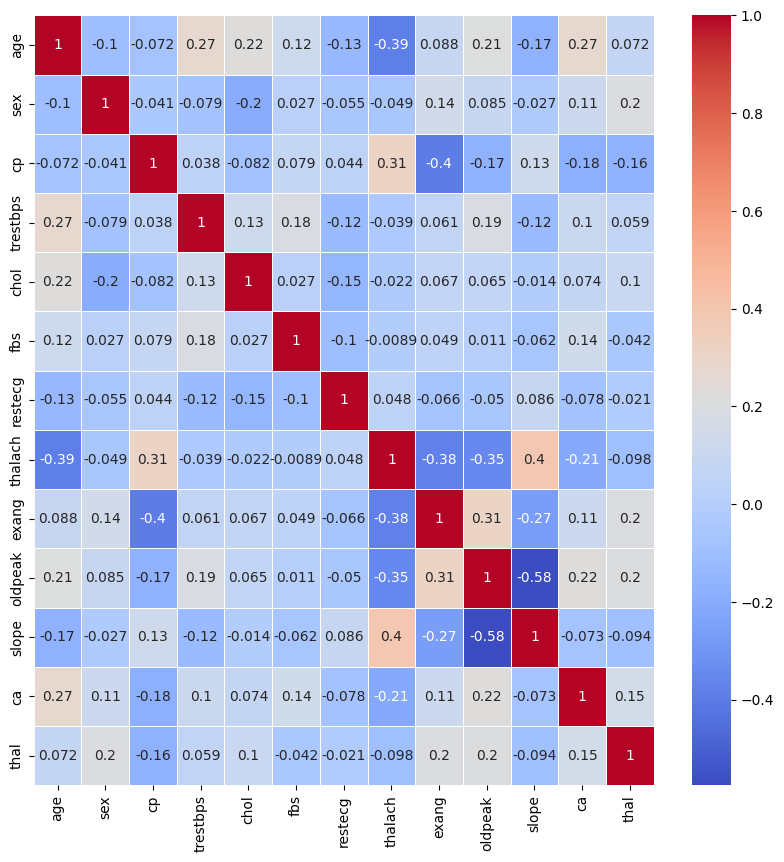

In [10]:
corr_matrix=X.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix,annot=True, cmap='coolwarm', linewidth=0.5)

In [11]:
X.shape

(1025, 13)

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
train_x, test_x, train_y, test_y= train_test_split(X, Y , test_size=0.2, random_state=42)

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [19]:
model1=Sequential([
    Dense(32, activation="relu", input_shape=(13,)),
    Dense(16, activation="relu"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dropout(0.1),
    Dense(2, activation="softmax")
])

    

C:\Users\thaku\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model2=Sequential([
    Dense(32, activation="relu", input_shape=(13,)),
    Dense(16, activation="relu"),
    Dense(16, activation="relu"),
    Dense(2, activation="softmax")
])

In [21]:
model1.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
model1.summary()

history1= model1.fit(train_x, train_y,
                     epochs=130,
                     batch_size=100,
                     validation_data=(test_x,test_y))

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ dense_8 (Dense)               │ (None, 32)            │          448 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_9 (Dense)               │ (None, 16)            │          528 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_2 (Dropout)           │ (None, 16)            │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_10 (Dense)              │ (None, 16)            │          272 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_3 (Dropout)           │ (None, 16)            │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_11 (Dense)              │ (None, 2)             │           34 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 1,282 (5.01 KB)

 Trainable params: 1,282 (5.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.4659 - loss: 0.7963 - val_accuracy: 0.5317 - val_loss: 0.7210
Epoch 2/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5317 - loss: 0.7206 - val_accuracy: 0.6146 - val_loss: 0.6671
Epoch 3/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5976 - loss: 0.6631 - val_accuracy: 0.6829 - val_loss: 0.6314
Epoch 4/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6427 - loss: 0.6419 - val_accuracy: 0.7268 - val_loss: 0.6011
Epoch 5/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6939 - loss: 0.5929 - val_accuracy: 0.7415 - val_loss: 0.5731
Epoch 6/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7244 - loss: 0.5604 - val_accuracy: 0.7659 - val_loss: 0.5450
Epoch 7/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7366 - loss: 0.5387 - val_accuracy: 0.7610 - val_loss: 0.5214
Epoch 8/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7500 - loss: 0.5209 - val_accuracy: 0.7659 - val_loss:

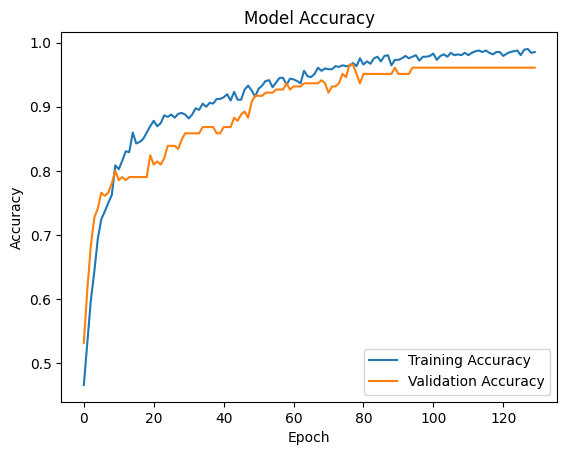

In [22]:
plt.plot(history1.history['accuracy'], label='Training Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

In [24]:
model2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
model2.summary()

history2=model2.fit(train_x, train_y,
                    epochs=130,
                    batch_size=100,
                    validation_data=(test_x, test_y))

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ dense_12 (Dense)              │ (None, 32)            │          448 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_13 (Dense)              │ (None, 16)            │          528 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_14 (Dense)              │ (None, 16)            │          272 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_15 (Dense)              │ (None, 2)             │           34 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 1,282 (5.01 KB)

 Trainable params: 1,282 (5.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.5780 - loss: 0.6880 - val_accuracy: 0.6244 - val_loss: 0.6547
Epoch 2/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6963 - loss: 0.6306 - val_accuracy: 0.6927 - val_loss: 0.6142
Epoch 3/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7646 - loss: 0.5878 - val_accuracy: 0.7317 - val_loss: 0.5730
Epoch 4/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7829 - loss: 0.5373 - val_accuracy: 0.7561 - val_loss: 0.5304
Epoch 5/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7988 - loss: 0.4863 - val_accuracy: 0.7463 - val_loss: 0.4948
Epoch 6/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8037 - loss: 0.4411 - val_accuracy: 0.7512 - val_loss: 0.4679
Epoch 7/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8183 - loss: 0.3997 - val_accuracy: 0.7659 - val_loss: 0.4459
Epoch 8/130
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8220 - loss: 0.3702 - val_accuracy: 0.7659 - val_loss:

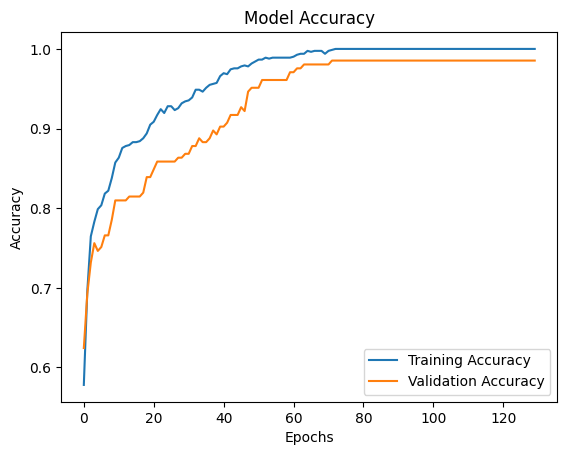

In [25]:
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

In [26]:
pred = model1.predict(test_x)
y_pred = np.argmax(pred, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [27]:
predictions = model1.predict(test_x)
print(predictions[:10])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
[[2.6355856e-05 9.9997365e-01]
 [3.1321479e-09 1.0000000e+00]
 [1.0000000e+00 4.7255568e-09]
 [1.0008356e-06 9.9999905e-01]
 [9.9971801e-01 2.8192112e-04]
 [5.5377502e-03 9.9446219e-01]
 [9.9998999e-01 9.9954705e-06]
 [1.0000000e+00 1.7461590e-08]
 [6.1740808e-04 9.9938262e-01]
 [1.0000000e+00 1.8458600e-08]]


In [28]:
y_pred = np.argmax(predictions, axis=1)
print(y_pred[:10])

[1 1 0 1 0 1 0 0 1 0]


In [29]:
print("Predicted:", y_pred[:10])
print("Actual:", test_y[:10])

Predicted: [1 1 0 1 0 1 0 0 1 0]
Actual: 527    1
359    1
447    0
31     1
621    0
590    1
905    0
737    0
76     1
948    0
Name: target, dtype: int64


In [30]:
model1.evaluate(test_x, test_y)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9610 - loss: 0.1200 


[0.12003273516893387, 0.9609755873680115]